In [18]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from google.colab import drive
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Montagem do Google Drive e Carregamento dos Dados

drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/CIC-ML/'

parquet_files = [
    'Benign-Monday-no-metadata.parquet',
    'Botnet-Friday-no-metadata.parquet',
    'Bruteforce-Tuesday-no-metadata.parquet',
    'DDoS-Friday-no-metadata.parquet',
    'DoS-Wednesday-no-metadata.parquet',
    'Infiltration-Thursday-no-metadata.parquet',
    'Portscan-Friday-no-metadata.parquet',
    'WebAttacks-Thursday-no-metadata.parquet',
]

df_list = []
for file_name in parquet_files:
  full_path = os.path.join(base_path, file_name)
  if os.path.exists(full_path):
    print(f'Carregando: {file_name}...')
    df_list.append(pd.read_parquet(full_path))
  else:
    print(f'Aviso: Arquivo {file_name} não encontrado.')

if not df_list:
  print('\nBuscando arquivos .parquet automaticamente...')
  all_found = glob.glob(os.path.join(base_path, '*.parquet'))
  for f in all_found:
    df_list.append(pd.read_parquet(f))

df = pd.concat(df_list, ignore_index=True)
df.drop_duplicates(inplace=True)
print(f'\nTotal de registros únicos carregados: {len(df):,}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carregando: Benign-Monday-no-metadata.parquet...
Carregando: Botnet-Friday-no-metadata.parquet...
Carregando: Bruteforce-Tuesday-no-metadata.parquet...
Carregando: DDoS-Friday-no-metadata.parquet...
Carregando: DoS-Wednesday-no-metadata.parquet...
Carregando: Infiltration-Thursday-no-metadata.parquet...
Carregando: Portscan-Friday-no-metadata.parquet...
Carregando: WebAttacks-Thursday-no-metadata.parquet...

Total de registros únicos carregados: 2,231,806


In [19]:
# 2. Análise Exploratória de Dados (EDA)

print('\n' + '=' * 50)
print('ANÁLISE EXPLORATÓRIA DE DADOS (EDA)')
print('=' * 50)

print(f'\nDimensões do DataFrame: {df.shape}')
print('\nPrimeiras linhas:')
print(df.head())

# Ajuste de nomes de colunas e limpeza de infinitos/nulos
df.columns = df.columns.str.strip()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Definir variável alvo y (0: Normal/Benign, 1: Ataque)
df['Target'] = df['Label'].apply(
    lambda x: 0 if str(x).strip().lower() == 'benign' else 1
)

print('\nDistribuição das Classes (Contagem e Porcentagem):')
counts = df['Target'].value_counts()
print(counts)
print(df['Target'].value_counts(normalize=True) * 100)


ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

Dimensões do DataFrame: (2231806, 78)

Primeiras linhas:
   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         6              4                  2                       0   
1         6              1                  2                       0   
2         6              3                  2                       0   
3         6              1                  2                       0   
4         6            609                  7                       4   

   Fwd Packets Length Total  Bwd Packets Length Total  Fwd Packet Length Max  \
0                        12                         0                      6   
1                        12                         0                      6   
2                        12                         0                      6   
3                        12                         0                      6   
4                       484                       414             

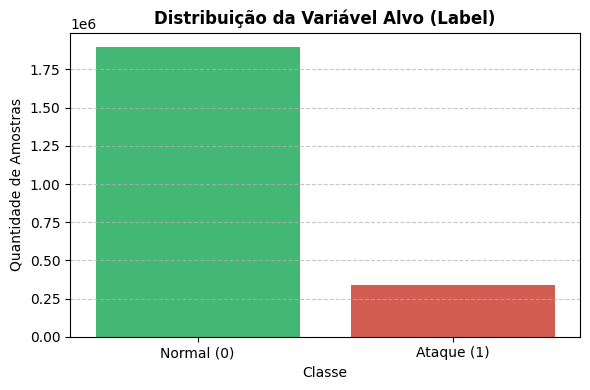

In [20]:
# Visualização 1: Distribuição das Classes (Normal vs Ataque)
plt.figure(figsize=(6, 4))
sns.countplot(
    x='Target', data=df, palette=['#2ecc71', '#e74c3c'], hue='Target', legend=False
)
plt.xticks(ticks=[0, 1], labels=['Normal (0)', 'Ataque (1)'])
plt.title('Distribuição da Variável Alvo (Label)', fontsize=12, fontweight='bold')
plt.xlabel('Classe')
plt.ylabel('Quantidade de Amostras')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
# 3. Pré-processamento e Divisão dos Dados

# Seleção de Features X (remover Label e Target)
X = df.drop(columns=['Label', 'Target'])
X = X.apply(pd.to_numeric, errors='coerce').dropna()
y = df.loc[X.index, 'Target']

# Remover colunas com variância zero (sem sinal informativo)
X = X.loc[:, X.std() > 0]
print(f'\nTotal de features selecionadas em X: {X.shape[1]}')

# Divisão Treino/Teste estratificada (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalonamento dos dados com StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Total de features selecionadas em X: 69


In [22]:
# 4. Treinamento da Regressão Logística

print('\n' + '=' * 50)
print('TREINAMENTO DO MODELO DE REGRESSÃO LOGÍSTICA')
print('=' * 50)

log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight='balanced'
)

log_reg.fit(X_train_scaled, y_train)
print('Treinamento concluído com sucesso!')


TREINAMENTO DO MODELO DE REGRESSÃO LOGÍSTICA
Treinamento concluído com sucesso!


In [23]:
# 5. Predição e Avaliação do Modelo

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Métricas Principais
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print('\n' + '=' * 50)
print('RELATÓRIO DE AVALIAÇÃO')
print('=' * 50)
print(f'Acurácia do Modelo: {acc:.4f} ({acc*100:.2f}%)')
print(f'Área sob a Curva ROC (AUC): {auc:.4f}')

print('\nRelatório de Classificação Detalhado:')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Ataque']))


RELATÓRIO DE AVALIAÇÃO
Acurácia do Modelo: 0.9459 (94.59%)
Área sob a Curva ROC (AUC): 0.9930

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

      Normal       0.99      0.94      0.97    379063
      Ataque       0.75      0.97      0.84     67299

    accuracy                           0.95    446362
   macro avg       0.87      0.96      0.91    446362
weighted avg       0.96      0.95      0.95    446362



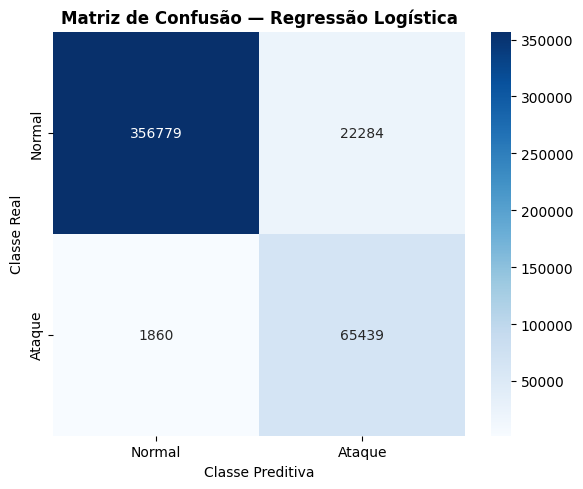

In [24]:
# Visualização 2: Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Ataque'],
    yticklabels=['Normal', 'Ataque'],
)
plt.title(
    'Matriz de Confusão — Regressão Logística', fontsize=12, fontweight='bold'
)
plt.xlabel('Classe Preditiva')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()

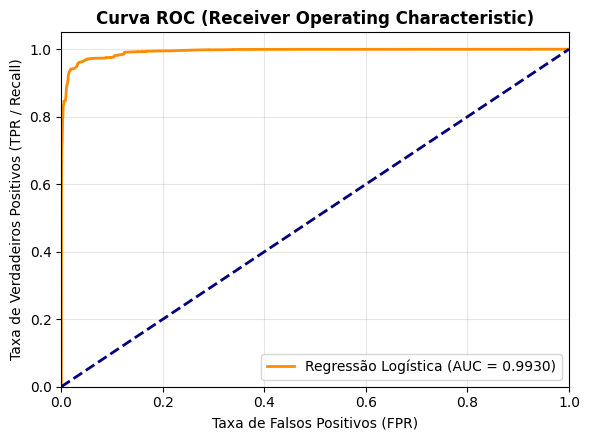

In [25]:
# Visualização 3: Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4.5))
plt.plot(
    fpr, tpr, color='darkorange', lw=2, label=f'Regressão Logística (AUC = {auc:.4f})'
)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR / Recall)')
plt.title('Curva ROC (Receiver Operating Characteristic)', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()